In [5]:
import numpy as np
import pandas as pd
import seaborn as sns

In [6]:
# Read in the files
balance_sheet = pd.read_excel("/content/Balance_Sheet.xlsx")
income_statement = pd.read_excel("/content/Income_Statement.xlsx")


In [7]:
# Merge both dataframes
df_ratios = pd.merge(income_statement, balance_sheet, on = ["Year", "company", "comp_type"])

In [8]:
# Profitability Ratio
df_ratios["profitability_ratio"] = (df_ratios["Total Revenue"] - df_ratios["Cost Of Goods Sold"])/df_ratios["Total Revenue"]


In [9]:
# Leverage Ratio
df_ratios["leverage_ratio"] = df_ratios["Total Liab"]/df_ratios["Total Stockholder Equity"]


In [10]:
print(df_ratios.pivot_table(index="comp_type", values="profitability_ratio"))
lowest_profitability = "fmcg"

           profitability_ratio
comp_type                     
fmcg                  0.514396
real_est              0.534848
tech                  0.572062


In [11]:

print(df_ratios.pivot_table(index="comp_type", values="profitability_ratio"))
lowest_profitability = "fmcg"

# Using pivot table to see the "comp_type" with the highest average leverage ratio
print(df_ratios.pivot_table(index="comp_type", values="leverage_ratio"))
highest_leverage = "real_est"

           profitability_ratio
comp_type                     
fmcg                  0.514396
real_est              0.534848
tech                  0.572062
           leverage_ratio
comp_type                
fmcg             2.997896
real_est         5.692041
tech             1.777448


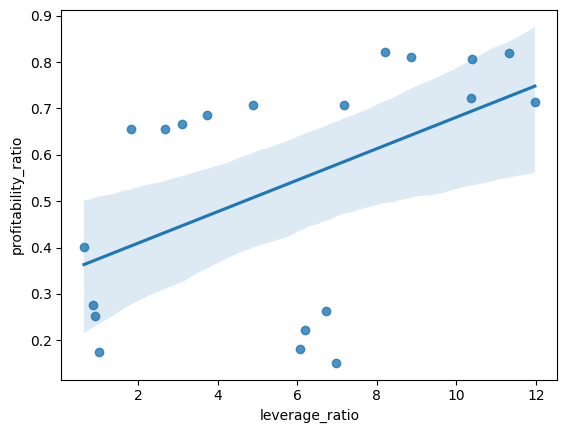

In [12]:
# Plot the leverage ratio on x-axis and profitability on y axis to see if real estate companies with higher leverage ratio have  higher profitability
df_real_est = df_ratios.loc[df_ratios["comp_type"]=="real_est"]
plot = sns.regplot(data=df_real_est, x="leverage_ratio", y="profitability_ratio")
relationship = "positive"